In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sb
import sqlite3

# Загрузка датасета и сохранение его в БД

In [4]:
df = pd.read_csv("Final_data.csv")
conn = sqlite3.connect("test.db")
df.to_sql("user", con=conn, if_exists="append", index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

# Удаляю ненужные категориальные поля и перевожу нужные в числовой формат

In [17]:
new_df = df.drop(["meal_name", "Workout_Type", "meal_type", "diet_type", "cooking_method", "Name of Exercise", "Benefit", "Target Muscle Group", "Equipment Needed", "Body Part", "Type of Muscle", "Workout", "Burns_Calories_Bin"], axis=1)
new_df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
new_df["Difficulty Level"] = df["Difficulty Level"].map({"Beginner": 0, "Intermediate": 1, "Advanced": 2})

# Матрица кареляции

<Axes: >

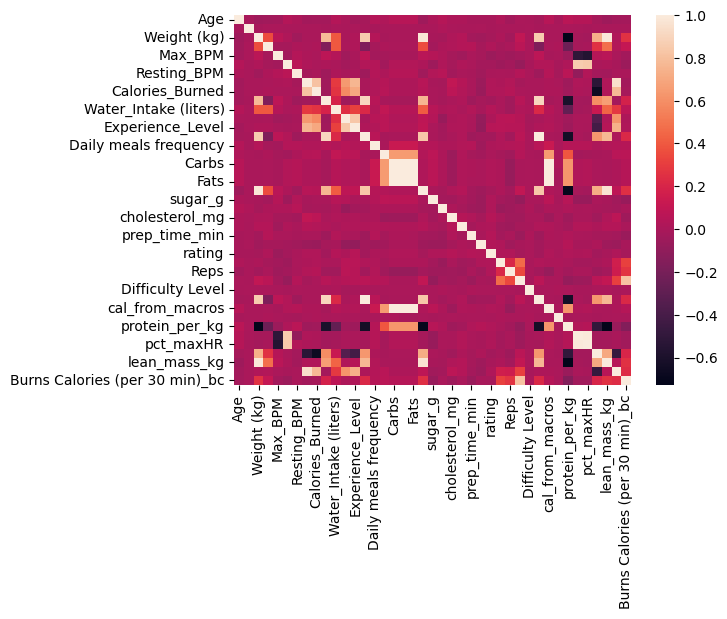

In [18]:
cor = new_df.corr(method="pearson", min_periods=1, numeric_only=False)
sb.heatmap(cor)

# Удаляю поля слабо коррелирующие с целевым полем *lean_mass_kg*

In [32]:
clean_df = new_df.drop(["Age", "Gender", "Fats", "sugar_g", "Daily meals frequency", "Carbs", "cholesterol_mg", "prep_time_min", "rating", "Reps", "Difficulty Level", "serving_size_g", "Sets", "cook_time_min"], axis=1)
clean_df = clean_df.drop(["Max_BPM", "Resting_BPM", "Calories_Burned", "Experience_Level", "Burns Calories (per 30 min)", "pct_maxHR", "Avg_BPM", "Session_Duration (hours)", "Workout_Frequency (days/week)", "sodium_mg", "pct_carbs", "pct_HRR"], axis=1)

# Ставли целевое поле на первое место в матрице

<Axes: >

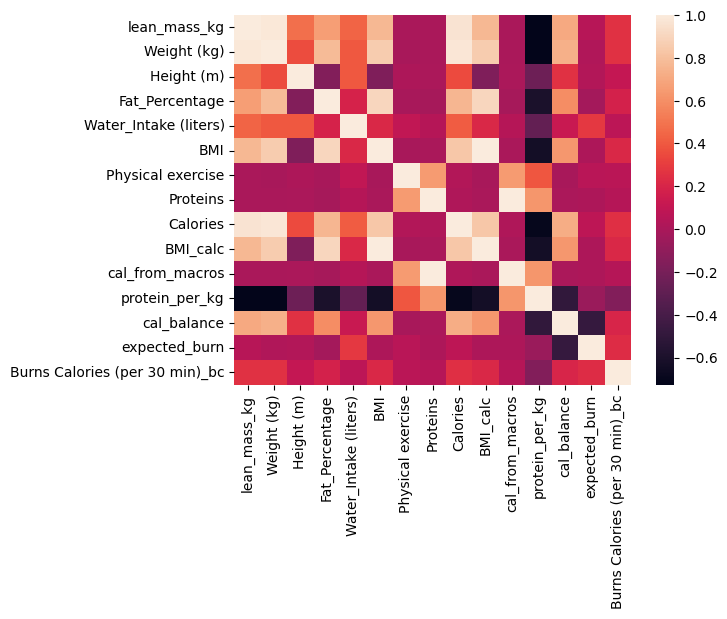

In [33]:
cor = clean_df.corr(method="pearson", min_periods=1, numeric_only=False)
order = ["lean_mass_kg"] + [col for col in cor.columns if col != 'lean_mass_kg']
cor = cor.loc[order, order]
sb.heatmap(cor)

# Сохраняю получившийся датасет

In [34]:
clean_df.to_csv("clean_df.csv")
clean_df.to_sql("clean_df", con=conn, if_exists="append", index=False)

20000

# Расшифровка полей

In [35]:
pd.read_csv("расшифровки.csv")

,столбец,описание,тип данных,кол-во Nan значений,единицы измерения,Unnamed: 5
0,Weight (kg),Вес человека в килограммах.,string,0,kg,NaN
1,Height (m),Рост человека в метрах.,string,0,m,NaN
2,Fat_Percentage,Процентное содержание жира в организме человека.,string,0,%,NaN
3,Water_Intake (liters),Среднесуточное потребление воды в литрах.,string,0,liter,NaN
4,BMI,Индекс массы тела - показатель содержания жира...,string,0,kg/m2,NaN
5,Physical exercise,Указывает на тип или частоту физической активн...,string,0,NaN,NaN
6,Proteins,Суточная норма потребления белка (в граммах).,string,0,Дальтоны,NaN
7,Calories,"Общее количество калорий, потребляемых с пищей...",string,0,NaN,NaN
8,BMI_calc,Индекс массы тела - показатель жировых отложен...,string,0,kg/m2,NaN
9,cal_from_macros,количество калорий из макронутриентов,string,0,NaN,NaN


# Визуализация данных

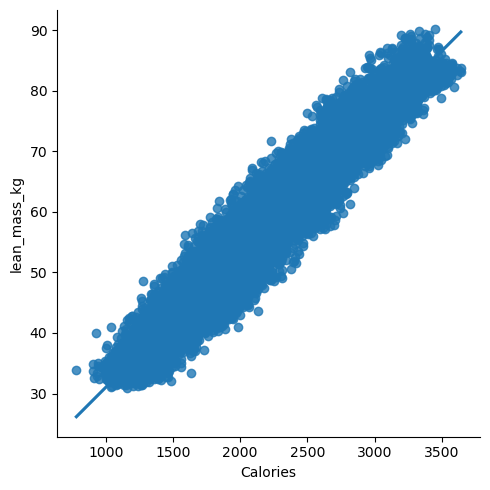

In [36]:
sb.lmplot(data=clean_df, x='Calories', y='lean_mass_kg')

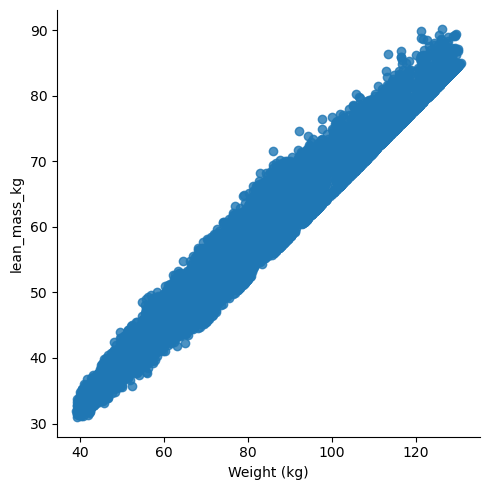

In [37]:
sb.lmplot(data=clean_df, x='Weight (kg)', y='lean_mass_kg')

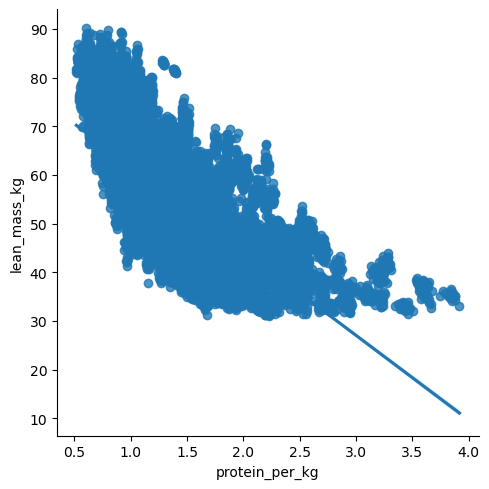

In [38]:
sb.lmplot(data=clean_df, x='protein_per_kg', y='lean_mass_kg')

# Простая линейная регрессия

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Weight (kg)', 'Calories']]
y = df['lean_mass_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)
print(model.coef_)
print(model.intercept_)

[0.55071498 0.00117273]
10.707301215420387


In [52]:
print(model.score(X_test, y_test))

0.9640591307391763


In [57]:
print(model.predict(np.array([[72.56, 1802]])))

[52.78043891]


C:\Users\demoexam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
